#  Pipeline ML & Data Mining — Sales Superstore
---
1. Imports
2. Chargement des Données
3. Description & Statistiques
4. Nettoyage
5. Exploration (EDA)
6. Préparation ML
7. Entraînement des Algorithmes
8. K-Means Clustering
9. **Évaluation Complète (Matrices, ROC, CV, Rapport)**

#  1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, silhouette_score
)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800','#00BCD4']
print('Imports OK')

Imports OK


# 2. Chargement des Données

In [4]:
# --- Charger depuis Google Drive ---
 #from google.colab import drive
 #drive.mount('/content/drive')
 #df = pd.read_csv('/content/drive/MyDrive/Sales.csv')

# --- Upload direct ---
#from google.colab import files
#uploaded = files.upload()

# Après l'upload, le fichier sera dans le répertoire courant
df = pd.read_csv('Sales.csv')   # ← adapter le chemin si besoin

print(f'✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

✅ Dataset chargé : 9800 lignes × 18 colonnes


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


#  3. Description & Statistiques

In [5]:
print('=== INFOS GÉNÉRALES ===')
df.info()

print('\n=== STATISTIQUES DESCRIPTIVES (Numériques) ===')
display(df.describe().round(2))

print('\n=== STATISTIQUES DESCRIPTIVES (Catégorielles) ===')
display(df.describe(include='object'))

print('\n=== VALEURS MANQUANTES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({'Manquantes': missing, 'Pourcentage %': missing_pct})[missing > 0])

print(f'\n=== DOUBLONS === {df.duplicated().sum()}')

print('\n=== VALEURS UNIQUES (colonnes catégorielles) ===')
for col in df.select_dtypes(include='object').columns:
    print(f'  {col:20s} → {df[col].nunique()} uniques : {list(df[col].unique()[:5])}')

=== INFOS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null

,Row ID,Postal Code,Sales
count,9800.00,9789.00,9800.00
mean,4900.50,55273.32,230.77
std,2829.16,32041.22,626.65
min,1.00,1040.00,0.44
25%,2450.75,23223.00,17.25
50%,4900.50,58103.00,54.49
75%,7350.25,90008.00,210.60
max,9800.00,99301.00,22638.48



=== STATISTIQUES DESCRIPTIVES (Catégorielles) ===


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47



=== VALEURS MANQUANTES ===


,Manquantes,Pourcentage %
Postal Code,11,0.11



=== DOUBLONS === 0

=== VALEURS UNIQUES (colonnes catégorielles) ===
  Order ID             → 4922 uniques : ['CA-2017-152156', 'CA-2017-138688', 'US-2016-108966', 'CA-2015-115812', 'CA-2018-114412']
  Order Date           → 1230 uniques : ['08/11/2017', '12/06/2017', '11/10/2016', '09/06/2015', '15/04/2018']
  Ship Date            → 1326 uniques : ['11/11/2017', '16/06/2017', '18/10/2016', '14/06/2015', '20/04/2018']
  Ship Mode            → 4 uniques : ['Second Class', 'Standard Class', 'First Class', 'Same Day']
  Customer ID          → 793 uniques : ['CG-12520', 'DV-13045', 'SO-20335', 'BH-11710', 'AA-10480']
  Customer Name        → 793 uniques : ['Claire Gute', 'Darrin Van Huff', "Sean O'Donnell", 'Brosina Hoffman', 'Andrew Allen']
  Segment              → 3 uniques : ['Consumer', 'Corporate', 'Home Office']
  Country              → 1 uniques : ['United States']
  City                 → 529 uniques : ['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord', 'Seattle']
  State  

#  4. Nettoyage des Données

In [15]:
df_clean = df.copy()

# Suppression des colonnes non pertinentes (identifiants)
cols_to_drop = ['Row ID','Order ID','Customer ID','Customer Name','Product ID','Product Name','Country']
df_clean.drop(columns=cols_to_drop, inplace=True)

# Gestion valeurs manquantes : Postal Code → médiane
df_clean['Postal Code'] = df_clean['Postal Code'].fillna(df_clean['Postal Code'].median())

# Extraction features temporelles depuis les dates
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], dayfirst=True)
df_clean['Ship Date']  = pd.to_datetime(df_clean['Ship Date'],  dayfirst=True)
df_clean['Order_Year']    = df_clean['Order Date'].dt.year    # Changed to snake_case
df_clean['Order_Month']   = df_clean['Order Date'].dt.month   # Changed to snake_case
df_clean['Order_Day']     = df_clean['Order Date'].dt.day     # Added Order_Day
df_clean['Shipping_Days'] = (df_clean['Ship Date'] - df_clean['Order Date']).dt.days # Changed to snake_case
df_clean.drop(columns=['Order Date','Ship Date'], inplace=True)

# Variable cible classification : 0=Faible vente, 1=Forte vente (seuil = médiane)
threshold = df_clean['Sales'].median()
df_clean['Sales_Class'] = (df_clean['Sales'] > threshold).astype(int)
print(f'Variable cible créée (seuil médiane={threshold:.2f}) :')
print(df_clean['Sales_Class'].value_counts())

# Encodage des variables catégorielles
le = LabelEncoder()

# List of categorical columns that should be renamed with '_enc' suffix
categorical_features_to_encode_and_rename = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

# Get all current object columns before encoding and renaming
all_object_cols_before_encoding = df_clean.select_dtypes(include='object').columns.tolist()

for col in all_object_cols_before_encoding:
    # Encode the column in place
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    # If this column is one of the target features, rename it with _enc suffix
    if col in categorical_features_to_encode_and_rename:
        df_clean.rename(columns={col: col + '_enc'}, inplace=True)

print(f'\n✅ Dataset nettoyé : {df_clean.shape}')
df_clean.head()

Variable cible créée (seuil médiane=54.49) :
Sales_Class
1    4900
0    4900
Name: count, dtype: int64

✅ Dataset nettoyé : (9800, 14)


,Ship Mode_enc,Segment_enc,City,State,Postal Code,Region_enc,Category_enc,Sub-Category_enc,Sales,Order_Year,Order_Month,Order_Day,Shipping_Days,Sales_Class
0,2,0,194,15,42420.0,2,0,4,261.9600,2017,11,8,3,1
1,2,0,194,15,42420.0,2,0,5,731.9400,2017,11,8,3,1
2,2,1,265,3,90036.0,3,1,10,14.6200,2017,6,12,4,0
3,3,0,153,8,33311.0,2,0,16,957.5775,2016,10,11,7,1
4,3,0,153,8,33311.0,2,1,14,22.3680,2016,10,11,7,0


#  5. Exploration des Données (EDA)

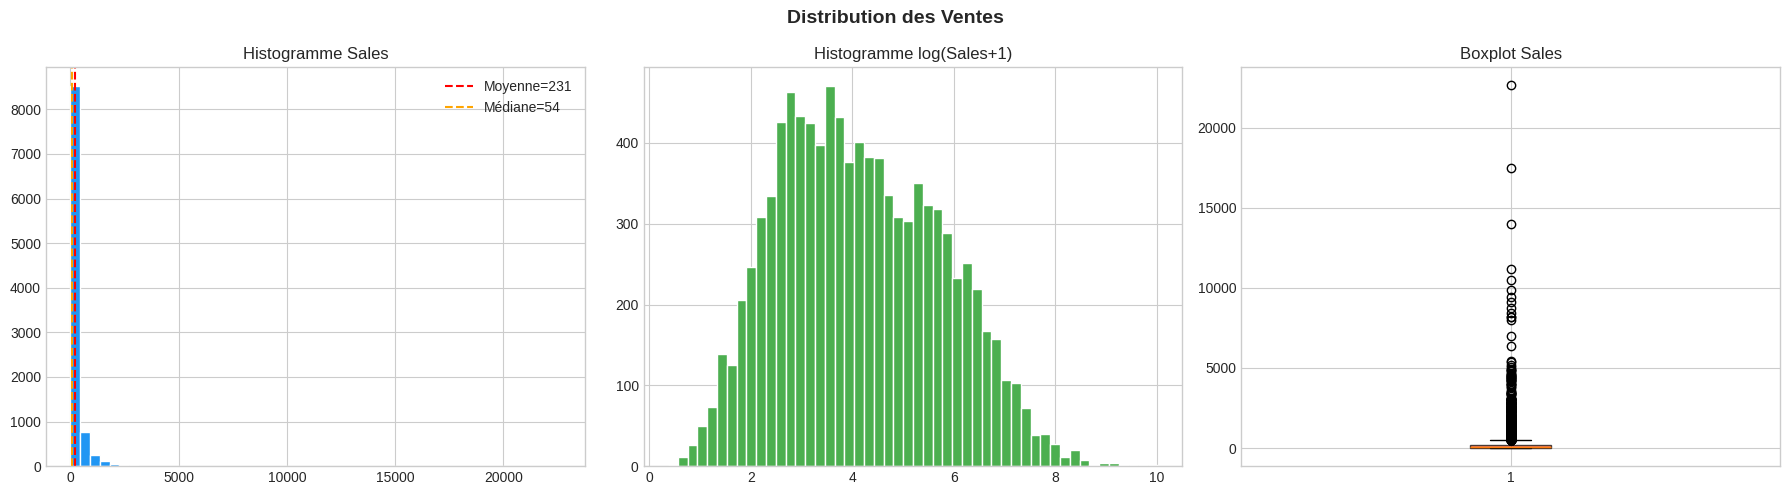

In [7]:
# Distribution Sales + Évolution temporelle
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution des Ventes', fontsize=14, fontweight='bold')

axes[0].hist(df['Sales'], bins=50, color=COLORS[0], edgecolor='white')
axes[0].axvline(df['Sales'].mean(),   color='red',    linestyle='--', label=f'Moyenne={df["Sales"].mean():.0f}')
axes[0].axvline(df['Sales'].median(), color='orange', linestyle='--', label=f'Médiane={df["Sales"].median():.0f}')
axes[0].set_title('Histogramme Sales')
axes[0].legend()

axes[1].hist(np.log1p(df['Sales']), bins=50, color=COLORS[1], edgecolor='white')
axes[1].set_title('Histogramme log(Sales+1)')

axes[2].boxplot(df['Sales'], patch_artist=True, boxprops=dict(facecolor=COLORS[2], alpha=0.7))
axes[2].set_title('Boxplot Sales')

plt.tight_layout()
plt.show()

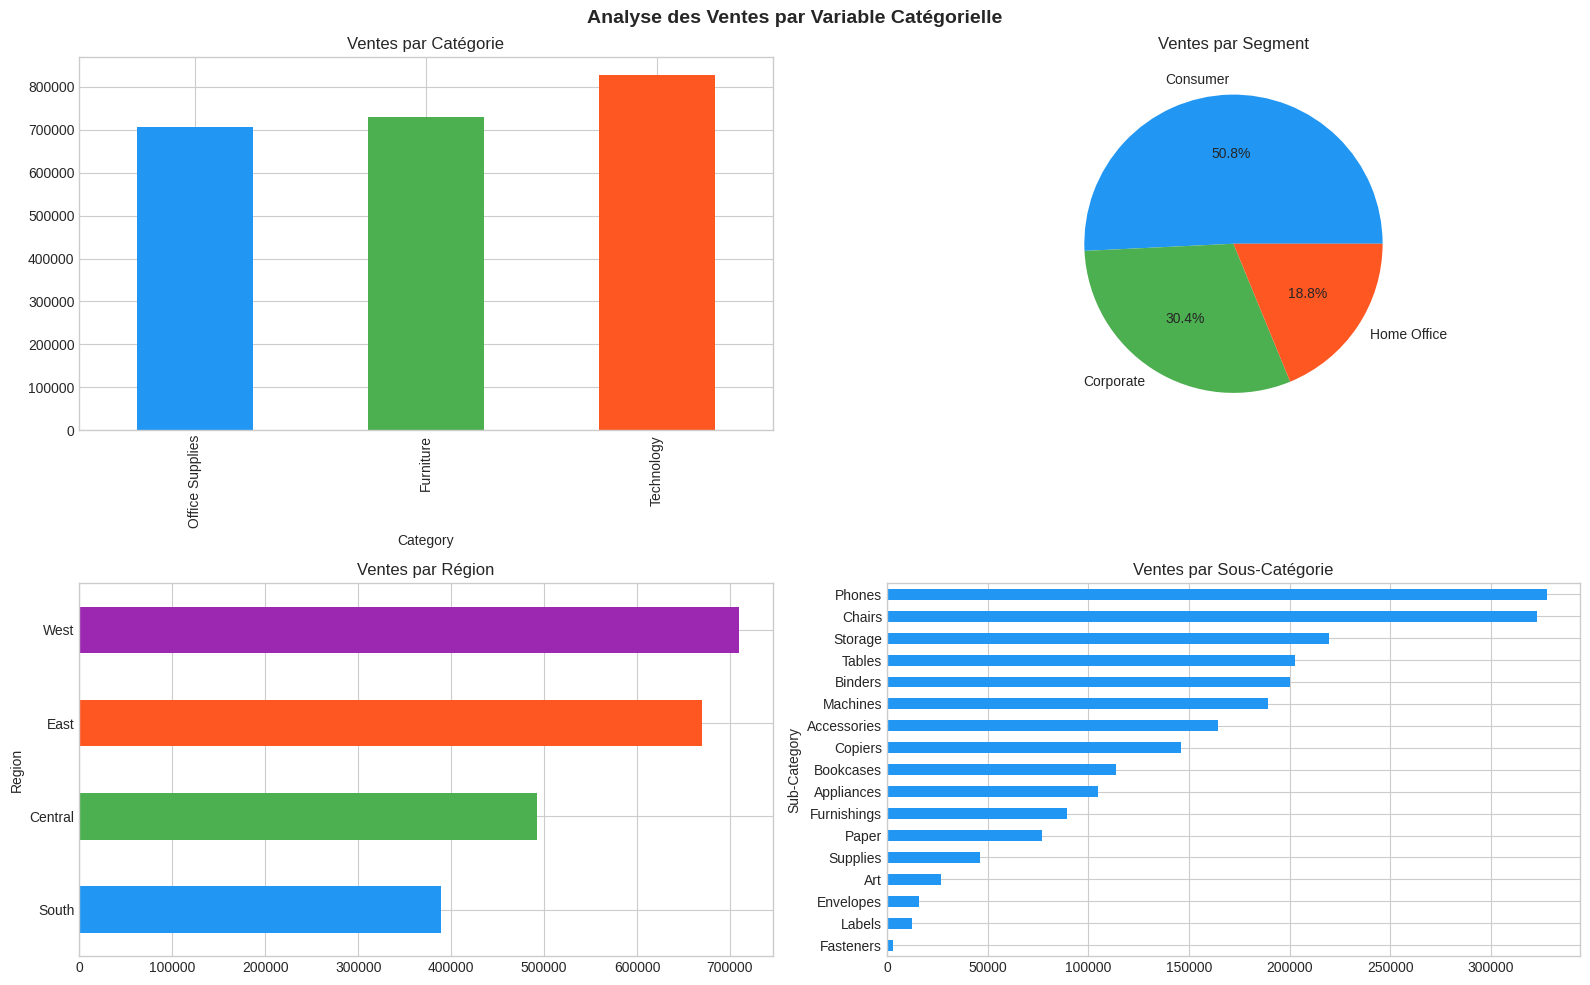

In [8]:
# Ventes par Catégorie, Segment, Région, Sous-Catégorie
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse des Ventes par Variable Catégorielle', fontsize=14, fontweight='bold')

df.groupby('Category')['Sales'].sum().sort_values().plot(kind='bar', ax=axes[0,0], color=COLORS[:3])
axes[0,0].set_title('Ventes par Catégorie')

seg = df.groupby('Segment')['Sales'].sum()
axes[0,1].pie(seg.values, labels=seg.index, autopct='%1.1f%%', colors=COLORS[:3])
axes[0,1].set_title('Ventes par Segment')

df.groupby('Region')['Sales'].sum().sort_values().plot(kind='barh', ax=axes[1,0], color=COLORS[:4])
axes[1,0].set_title('Ventes par Région')

df.groupby('Sub-Category')['Sales'].sum().sort_values().plot(kind='barh', ax=axes[1,1], color=COLORS[0])
axes[1,1].set_title('Ventes par Sous-Catégorie')

plt.tight_layout()
plt.show()

In [13]:
# 4. Sélection des features pour la régression
feature_cols = [
    'Ship Mode_enc', 'Segment_enc', 'Region_enc',
    'Category_enc', 'Sub-Category_enc',
    'Order_Year', 'Order_Month', 'Order_Day', 'Shipping_Days',
    'Postal Code'
]

X = df_clean[feature_cols]
y = df_clean['Sales']
y_log = np.log1p(y)  # Transformation log pour normaliser la cible

print(f'\n✅ Features sélectionnées : {feature_cols}')
print(f'📐 Dimensions X : {X.shape}')
print(f'📐 Dimensions y : {y.shape}')


✅ Features sélectionnées : ['Ship Mode_enc', 'Segment_enc', 'Region_enc', 'Category_enc', 'Sub-Category_enc', 'Order_Year', 'Order_Month', 'Order_Day', 'Shipping_Days', 'Postal Code']
📐 Dimensions X : (9800, 10)
📐 Dimensions y : (9800,)


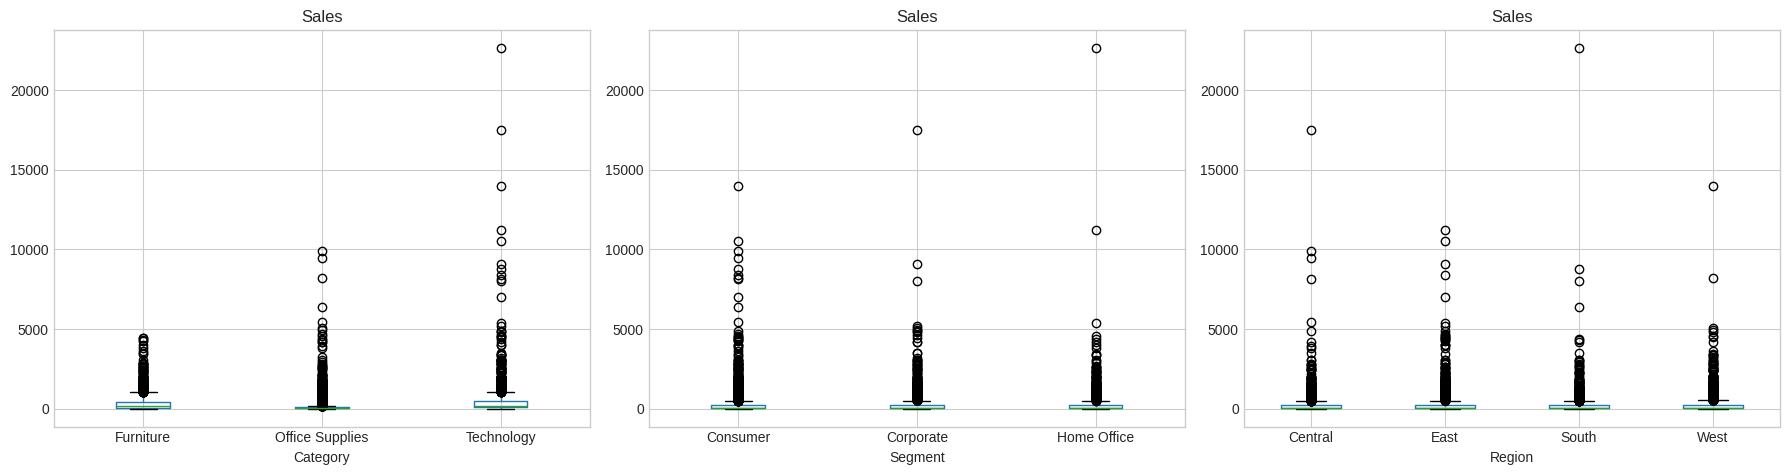

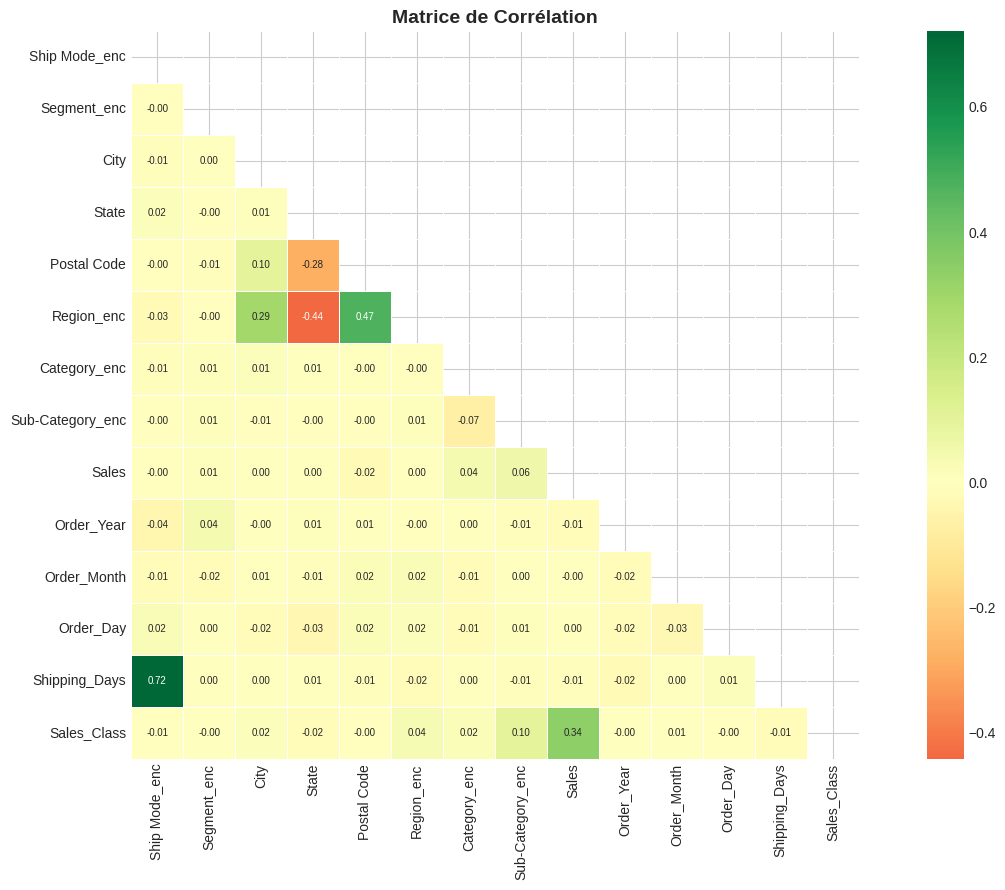

In [14]:
# Boxplots détection outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boxplots : Détection des Outliers', fontsize=13, fontweight='bold')
df.boxplot(column='Sales', by='Category', ax=axes[0])
df.boxplot(column='Sales', by='Segment',  ax=axes[1])
df.boxplot(column='Sales', by='Region',   ax=axes[2])
plt.suptitle('')
plt.tight_layout()
plt.show()

# Heatmap corrélation
fig, ax = plt.subplots(figsize=(14, 9))
corr = df_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

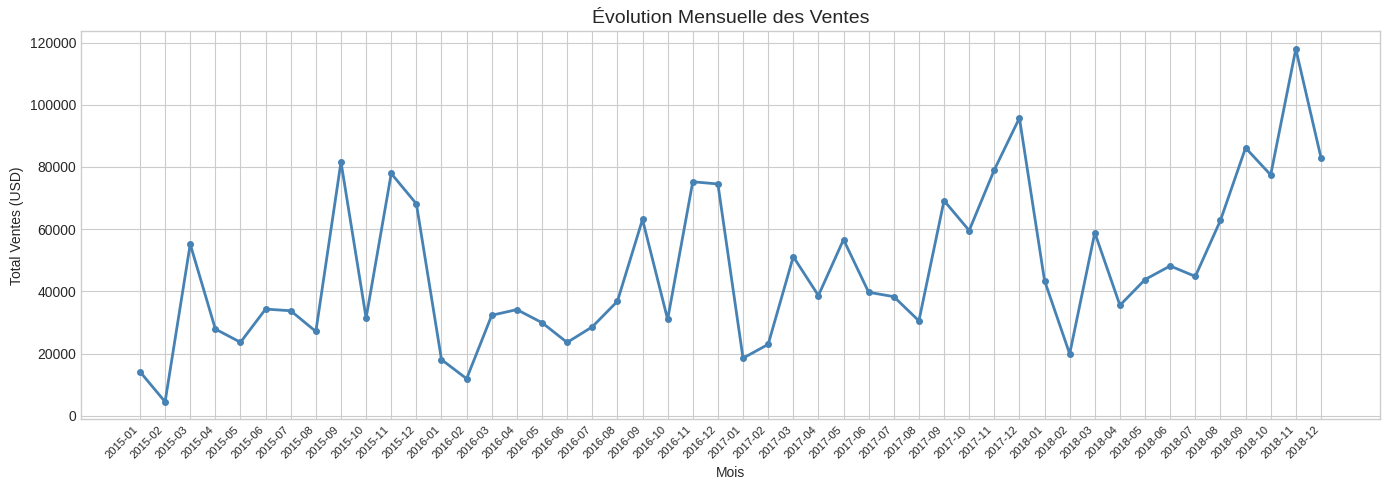

In [16]:
# Évolution temporelle des ventes
#df = pd.read_csv('Sales.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', linewidth=2, color='steelblue', markersize=4)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Évolution Mensuelle des Ventes', fontsize=14)
plt.ylabel('Total Ventes (USD)')
plt.xlabel('Mois')
plt.tight_layout()
plt.savefig('evolution_ventes.png', dpi=150)
plt.show()

#  6. Préparation ML

In [17]:
feature_cols = [c for c in df_clean.columns if c not in ['Sales', 'Sales_Class']]
X       = df_clean[feature_cols]
y_class = df_clean['Sales_Class']
y_reg   = df_clean['Sales']

# Normalisation
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

print(f' Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f' Features ({len(feature_cols)}) : {feature_cols}')

 Train : 7840 | Test : 1960
 Features (12) : ['Ship Mode_enc', 'Segment_enc', 'City', 'State', 'Postal Code', 'Region_enc', 'Category_enc', 'Sub-Category_enc', 'Order_Year', 'Order_Month', 'Order_Day', 'Shipping_Days']


#  7. Entraînement des Algorithmes

=== ENTRAÎNEMENT EN COURS... ===
  ✅ KNN (K=1) — Accuracy=0.5903 | F1=0.5829 | AUC=0.5903
  ✅ KNN (K=3) — Accuracy=0.6388 | F1=0.6234 | AUC=0.6666
  ✅ KNN (K=5) — Accuracy=0.6459 | F1=0.6281 | AUC=0.6856
  ✅ KNN (K=7) — Accuracy=0.6633 | F1=0.6448 | AUC=0.7040
  ✅ Arbre de Décision — Accuracy=0.7587 | F1=0.7347 | AUC=0.8128
  ✅ Random Forest — Accuracy=0.7658 | F1=0.7549 | AUC=0.8221
  ✅ SVM Linéaire — Accuracy=0.5423 | F1=0.4969 | AUC=0.5805
  ✅ Régression Logistique — Accuracy=0.5378 | F1=0.5276 | AUC=0.5559
  ✅ Régression Linéaire — R²=0.0042 | RMSE=815.82

✅ Tous les modèles entraînés !


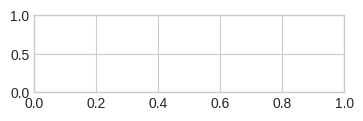

In [20]:

# DICTIONNAIRE POUR STOCKER TOUS LES RÉSULTATS
# ============================================================
results = {}   # résultats classification

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Entraîne un modèle et stocke ses prédictions + métriques."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    cv     = cross_val_score(model, X_scaled, y_class, cv=5, scoring='accuracy')
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
        'AUC'      : roc_auc_score(y_te, y_prob),
        'CV_mean'  : cv.mean(),
        'CV_std'   : cv.std()
    }
    print(f'  ✅ {name} — Accuracy={results[name]["Accuracy"]:.4f} | F1={results[name]["F1"]:.4f} | AUC={results[name]["AUC"]:.4f}')

print('=== ENTRAÎNEMENT EN COURS... ===')

# K-NN : K = 1, 3, 5, 7
for k in [1, 3, 5, 7]:
    evaluate_model(f'KNN (K={k})', KNeighborsClassifier(n_neighbors=k), X_train, X_test, y_train, y_test)

# Arbre de Décision
evaluate_model('Arbre de Décision', DecisionTreeClassifier(max_depth=5, random_state=42), X_train, X_test, y_train, y_test)

# Random Forest
evaluate_model('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test)

# SVM Linéaire
evaluate_model('SVM Linéaire', SVC(kernel='linear', probability=True, random_state=42), X_train, X_test, y_train, y_test)

# Régression Logistique
evaluate_model('Régression Logistique', LogisticRegression(max_iter=1000, random_state=42), X_train, X_test, y_train, y_test)

# Régression Linéaire (séparée car c'est de la régression)
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
y_pred_linreg = lin_reg.predict(X_test_r)
lin_reg_results = {
    'MAE' : mean_absolute_error(y_test_r, y_pred_linreg),
    'MSE' : mean_squared_error(y_test_r, y_pred_linreg),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred_linreg)),
    'R2'  : r2_score(y_test_r, y_pred_linreg),
    'CV_R2': cross_val_score(LinearRegression(), X_scaled, y_reg, cv=5, scoring='r2').mean()
}

print(f'  ✅ Régression Linéaire — R²={lin_reg_results["R2"]:.4f} | RMSE={lin_reg_results["RMSE"]:.2f}')

print('\n✅ Tous les modèles entraînés !')

In [22]:
from sklearn.ensemble import GradientBoostingClassifier  # XGBoost-like via sklearn

feature_cols = [c for c in df_clean.columns if c not in ['Sales', 'Sales_Class']]
X       = df_clean[feature_cols]
y_class = df_clean['Sales_Class']
y_reg   = df_clean['Sales']

# Normalisation
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

print(f' Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f' Features ({len(feature_cols)}) : {feature_cols}')
results = {}   # résultats classification

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Entraîne un modèle et stocke ses prédictions + métriques."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    cv     = cross_val_score(model, X_scaled, y_class, cv=5, scoring='accuracy')
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
        'AUC'      : roc_auc_score(y_te, y_prob),
        'CV_mean'  : cv.mean(),
        'CV_std'   : cv.std()
    }
    print(f'  ✅ {name} — Accuracy={results[name]["Accuracy"]:.4f} | F1={results[name]["F1"]:.4f} | AUC={results[name]["AUC"]:.4f}')

print('=== ENTRAÎNEMENT EN COURS... ===')

# K-NN : K = 1, 3, 5, 7
for k in [1, 3, 5, 7]:
    evaluate_model(f'KNN (K={k})', KNeighborsClassifier(n_neighbors=k), X_train, X_test, y_train, y_test)

# Arbre de Décision
evaluate_model('Arbre de Décision', DecisionTreeClassifier(max_depth=5, random_state=42), X_train, X_test, y_train, y_test)

# Random Forest
evaluate_model('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test)

# SVM Linéaire
evaluate_model('SVM Linéaire', SVC(kernel='linear', probability=True, random_state=42), X_train, X_test, y_train, y_test)

# Régression Logistique
evaluate_model('Régression Logistique', LogisticRegression(max_iter=1000, random_state=42), X_train, X_test, y_train, y_test)

# ── XGBoost Classification ──────────────────────────────────────────────────
evaluate_model(
    'XGBoost',
    GradientBoostingClassifier(
        n_estimators=100,   # nombre d'arbres (article Chen & Guestrin : T rounds)
        learning_rate=0.1,  # η : shrinkage pour éviter l'overfitting
        max_depth=5,        # profondeur max de chaque arbre weak learner
        subsample=0.8,      # stochastic boosting : fraction des données par arbre
        random_state=42
    ),
    X_train, X_test, y_train, y_test
)
# ────────────────────────────────────────────────────────────────────────────

# Régression Linéaire (séparée car c'est de la régression)
from sklearn.ensemble import GradientBoostingRegressor

lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
y_pred_linreg = lin_reg.predict(X_test_r)
lin_reg_results = {
    'MAE' : mean_absolute_error(y_test_r, y_pred_linreg),
    'MSE' : mean_squared_error(y_test_r, y_pred_linreg),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred_linreg)),
    'R2'  : r2_score(y_test_r, y_pred_linreg),
    'CV_R2': cross_val_score(LinearRegression(), X_scaled, y_reg, cv=5, scoring='r2').mean()
}
print(f'  ✅ Régression Linéaire — R²={lin_reg_results["R2"]:.4f} | RMSE={lin_reg_results["RMSE"]:.2f}')

# ── XGBoost Régression ──────────────────────────────────────────────────────
xgb_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
xgb_reg.fit(X_train_r, y_train_r)
y_pred_xgb = xgb_reg.predict(X_test_r)
xgb_reg_results = {
    'MAE' : mean_absolute_error(y_test_r, y_pred_xgb),
    'MSE' : mean_squared_error(y_test_r, y_pred_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred_xgb)),
    'R2'  : r2_score(y_test_r, y_pred_xgb),
    'CV_R2': cross_val_score(GradientBoostingRegressor(n_estimators=100, random_state=42),
                             X_scaled, y_reg, cv=5, scoring='r2').mean()
}
print(f'  ✅ XGBoost Régression — R²={xgb_reg_results["R2"]:.4f} | RMSE={xgb_reg_results["RMSE"]:.2f}')
# ────────────────────────────────────────────────────────────────────────────

print('\n✅ Tous les modèles entraînés !')

 Train : 7840 | Test : 1960
 Features (12) : ['Ship Mode_enc', 'Segment_enc', 'City', 'State', 'Postal Code', 'Region_enc', 'Category_enc', 'Sub-Category_enc', 'Order_Year', 'Order_Month', 'Order_Day', 'Shipping_Days']
=== ENTRAÎNEMENT EN COURS... ===
  ✅ KNN (K=1) — Accuracy=0.5903 | F1=0.5829 | AUC=0.5903
  ✅ KNN (K=3) — Accuracy=0.6388 | F1=0.6234 | AUC=0.6666
  ✅ KNN (K=5) — Accuracy=0.6459 | F1=0.6281 | AUC=0.6856
  ✅ KNN (K=7) — Accuracy=0.6633 | F1=0.6448 | AUC=0.7040
  ✅ Arbre de Décision — Accuracy=0.7587 | F1=0.7347 | AUC=0.8128
  ✅ Random Forest — Accuracy=0.7658 | F1=0.7549 | AUC=0.8221
  ✅ SVM Linéaire — Accuracy=0.5423 | F1=0.4969 | AUC=0.5805
  ✅ Régression Logistique — Accuracy=0.5378 | F1=0.5276 | AUC=0.5559
  ✅ XGBoost — Accuracy=0.7617 | F1=0.7463 | AUC=0.8287
  ✅ Régression Linéaire — R²=0.0042 | RMSE=815.82
  ✅ XGBoost Régression — R²=0.0738 | RMSE=786.81

✅ Tous les modèles entraînés !


#  8. K-Means Clustering

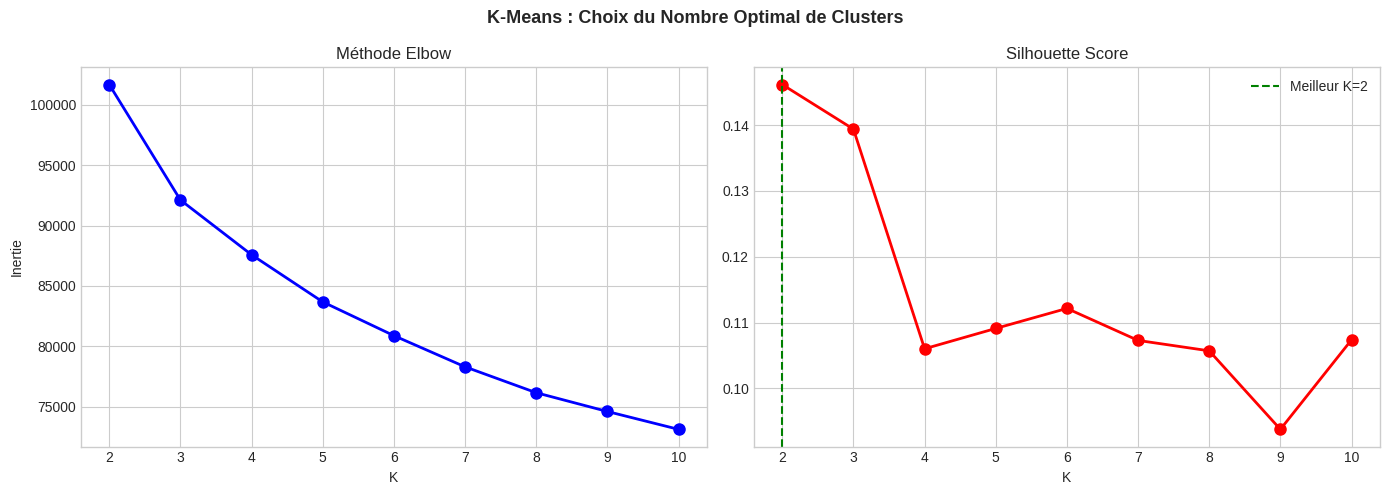

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


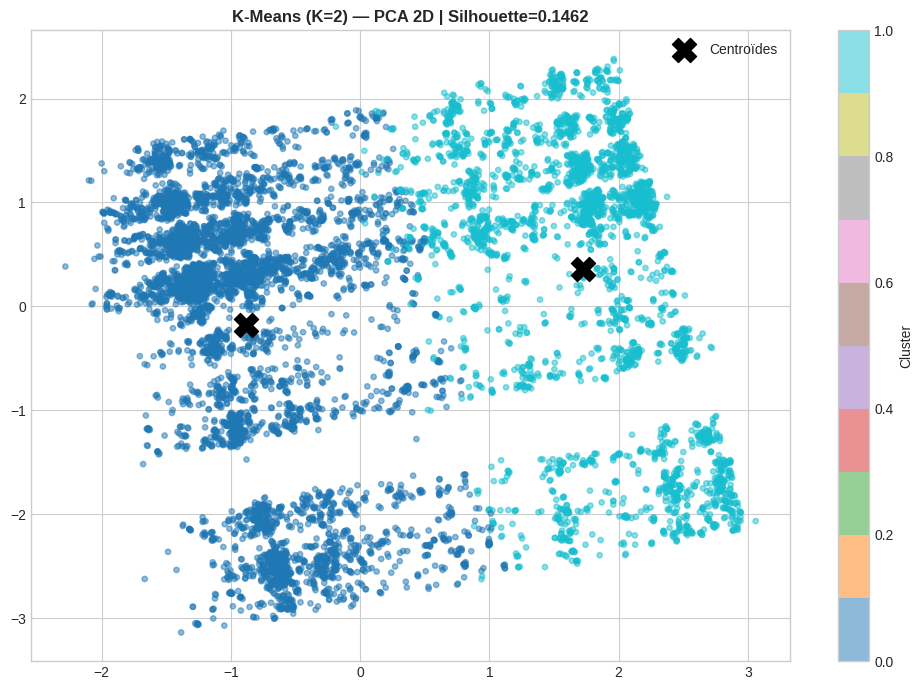

✅ K optimal=2 | Silhouette=0.1462 | Inertie=101670.13


In [23]:
# Méthode Elbow + Silhouette
K_range = range(2, 11)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means : Choix du Nombre Optimal de Clusters', fontsize=13, fontweight='bold')
axes[0].plot(list(K_range), inertias, 'bo-', lw=2, markersize=8)
axes[0].set_title('Méthode Elbow')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertie')

optimal_k = list(K_range)[np.argmax(silhouettes)]
axes[1].plot(list(K_range), silhouettes, 'ro-', lw=2, markersize=8)
axes[1].axvline(optimal_k, color='green', linestyle='--', label=f'Meilleur K={optimal_k}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].legend()
plt.tight_layout()
plt.show()

# K-Means final
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)
sil_final = silhouette_score(X_scaled, cluster_labels)

# Visualisation PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.5, s=15)
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=300, zorder=5, label='Centroïdes')
ax.set_title(f'K-Means (K={optimal_k}) — PCA 2D | Silhouette={sil_final:.4f}', fontsize=12, fontweight='bold')
ax.legend()
plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

print(f' K optimal={optimal_k} | Silhouette={sil_final:.4f} | Inertie={km_final.inertia_:.2f}')

#  9. Évaluation Complète de Tous les Modèles
## 9.1 Matrices de Confusion

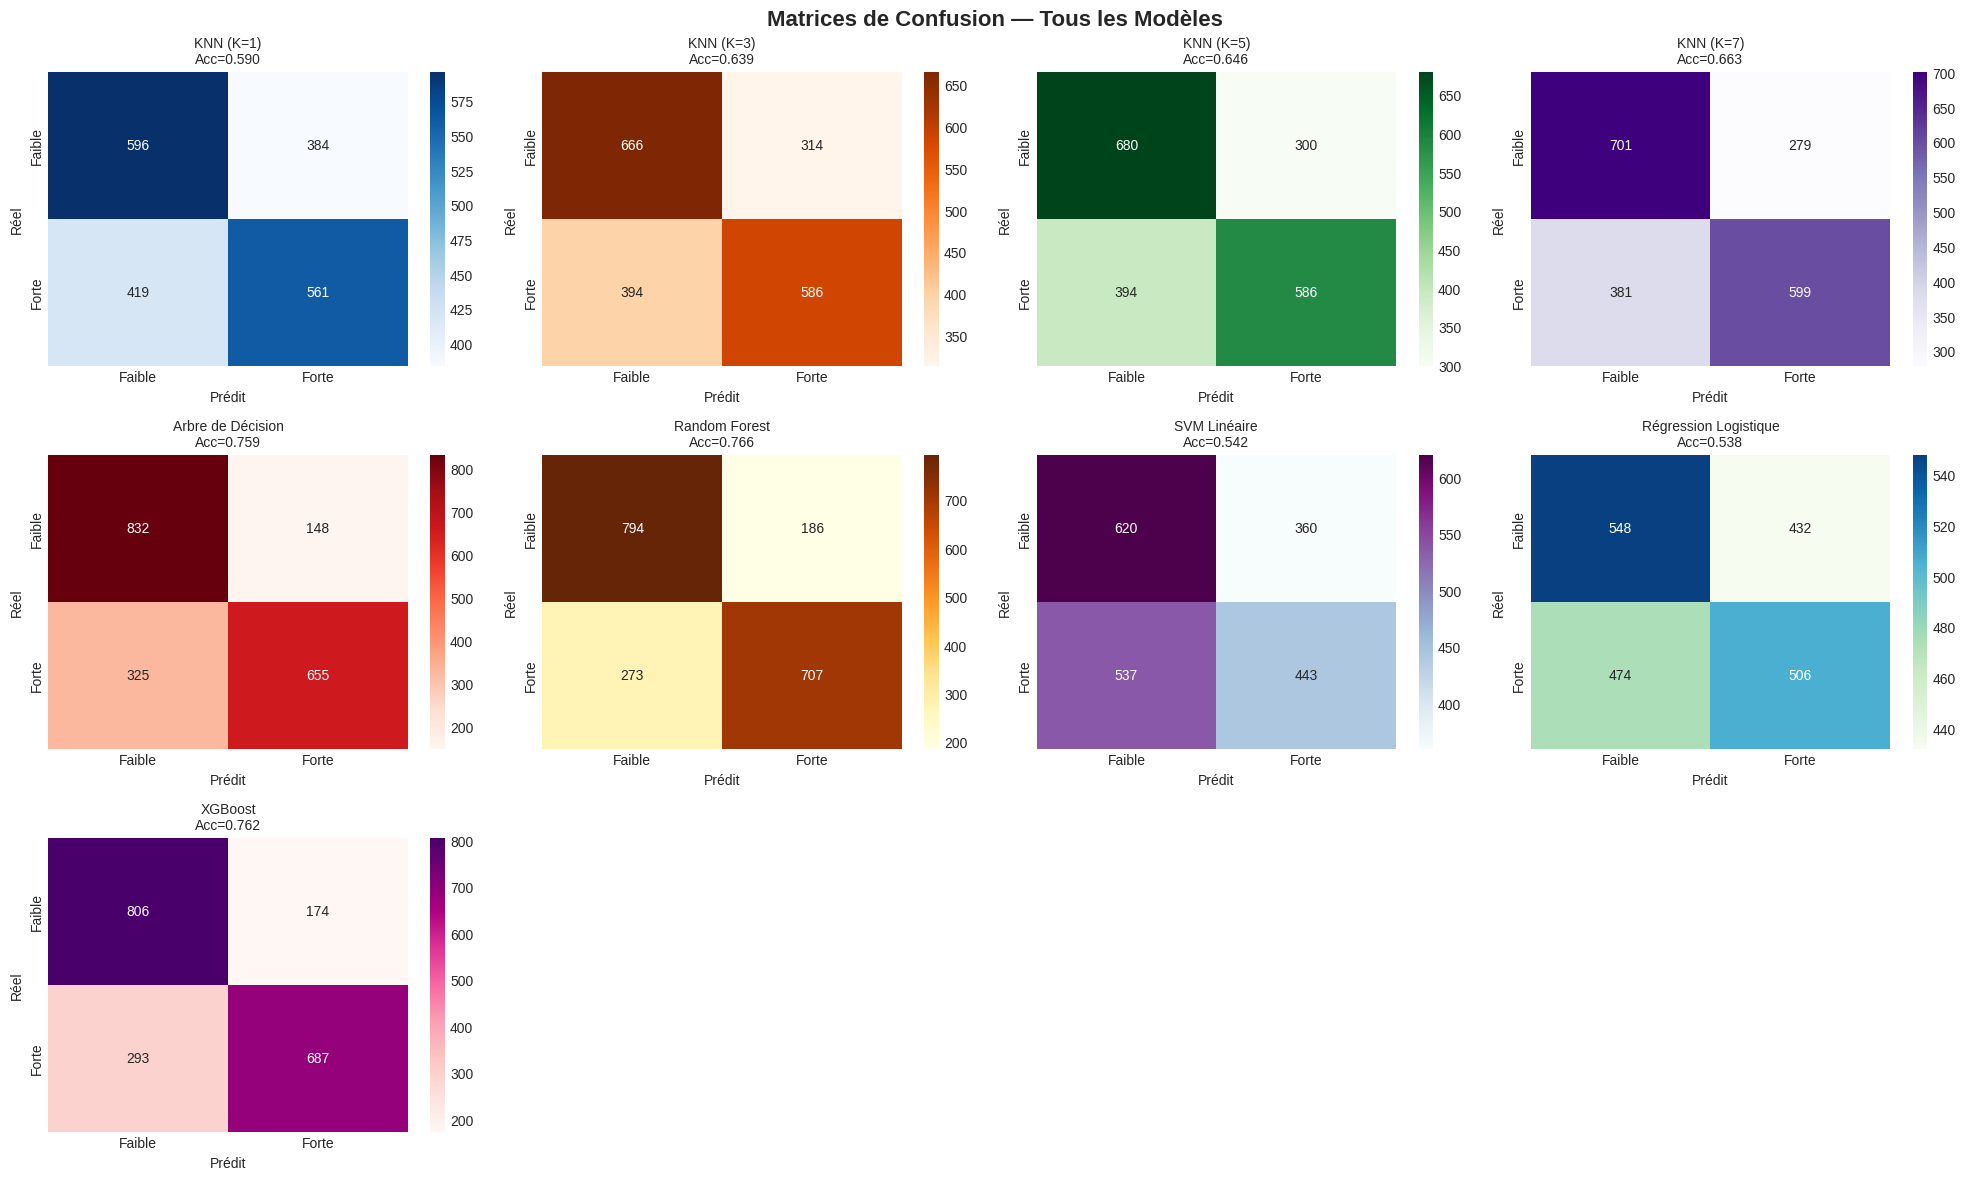

In [24]:
# ============================================================
# MATRICES DE CONFUSION — TOUS LES MODÈLES
# ============================================================
model_names = list(results.keys())
n = len(model_names)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*5, rows*4))
fig.suptitle('Matrices de Confusion — Tous les Modèles', fontsize=16, fontweight='bold')
axes = axes.flatten()

cmaps = ['Blues','Oranges','Greens','Purples','Reds','YlOrBr','BuPu','GnBu','RdPu','PuBu']

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i % len(cmaps)],
                xticklabels=['Faible','Forte'],
                yticklabels=['Faible','Forte'], ax=axes[i])
    axes[i].set_title(f'{name}\nAcc={results[name]["Accuracy"]:.3f}', fontsize=10)
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

# Masquer les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.2 Courbes ROC & AUC — Tous les Modèles

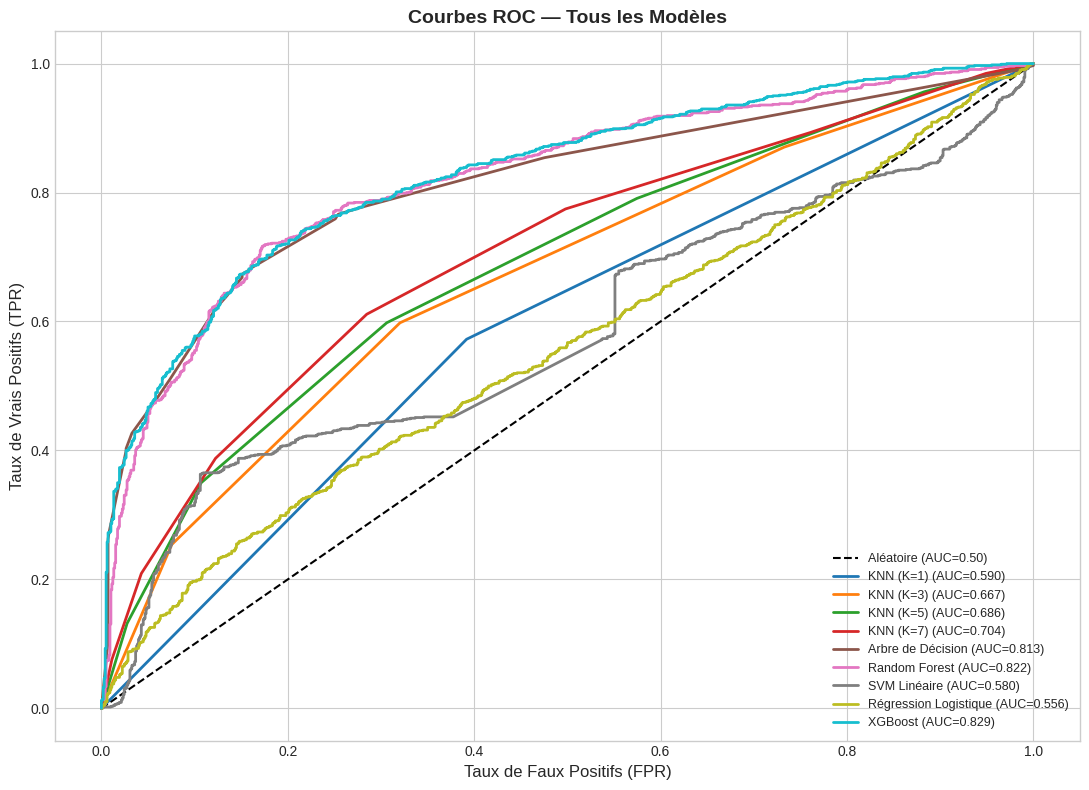

In [25]:
# ============================================================
# COURBES ROC — TOUS LES MODÈLES
# ============================================================
palette = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

fig, ax = plt.subplots(figsize=(11, 8))
ax.plot([0,1],[0,1],'k--', lw=1.5, label='Aléatoire (AUC=0.50)')

for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc_val = results[name]['AUC']
    ax.plot(fpr, tpr, color=palette[i], lw=2, label=f'{name} (AUC={auc_val:.3f})')

ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC — Tous les Modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('roc_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.3 Cross-Validation (5-Fold) — Tous les Modèles

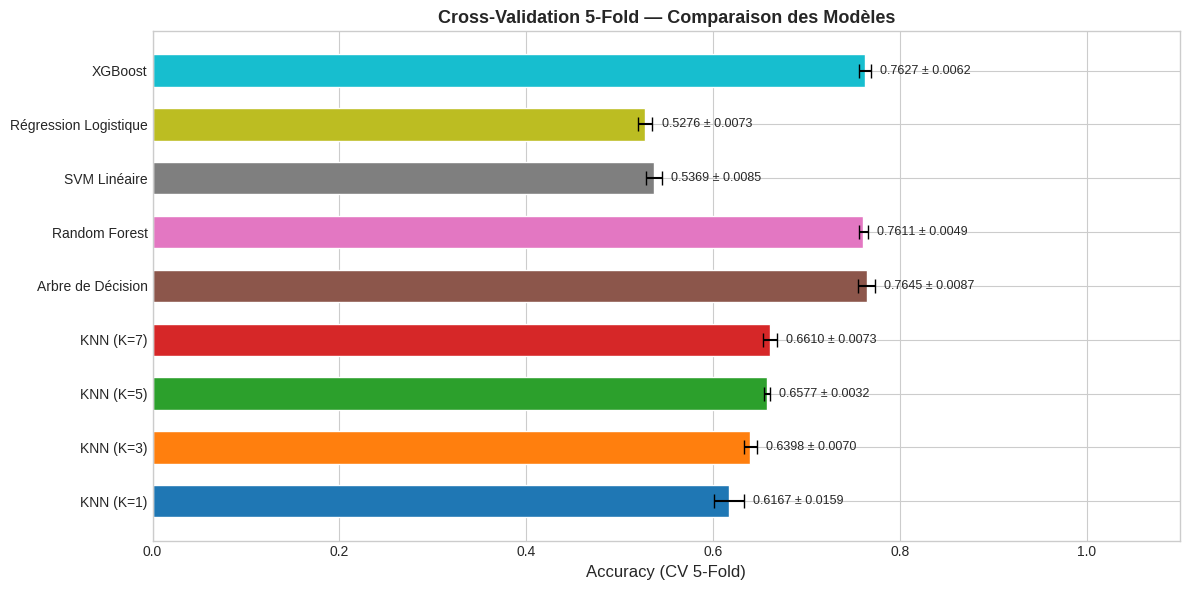

In [26]:
# ============================================================
# CROSS-VALIDATION — TOUS LES MODÈLES
# ============================================================
cv_means = [results[n]['CV_mean'] for n in model_names]
cv_stds  = [results[n]['CV_std']  for n in model_names]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(model_names, cv_means, xerr=cv_stds, color=palette,
               edgecolor='white', height=0.6, capsize=5)
ax.set_xlabel('Accuracy (CV 5-Fold)', fontsize=12)
ax.set_title('Cross-Validation 5-Fold — Comparaison des Modèles', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)
for bar, val, std in zip(bars, cv_means, cv_stds):
    ax.text(val + std + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ± {std:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.4 Rapport Final Comparatif

In [27]:
# ============================================================
# TABLEAU COMPARATIF FINAL
# ============================================================
report_data = []
for name, r in results.items():
    report_data.append({
        'Modèle'   : name,
        'Accuracy' : round(r['Accuracy'], 4),
        'Precision': round(r['Precision'], 4),
        'Recall'   : round(r['Recall'], 4),
        'F1-Score' : round(r['F1'], 4),
        'AUC'      : round(r['AUC'], 4),
        'CV Mean'  : round(r['CV_mean'], 4),
        'CV Std'   : round(r['CV_std'], 4)
    })

df_report = pd.DataFrame(report_data).sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_report.index += 1

print('='*90)
print('                    RAPPORT FINAL — MODÈLES DE CLASSIFICATION')
print('='*90)
display(df_report)

best = df_report.iloc[0]
print(f'\n MEILLEUR MODÈLE : {best["Modèle"]}')
print(f'   Accuracy  : {best["Accuracy"]}')
print(f'   Precision : {best["Precision"]}')
print(f'   Recall    : {best["Recall"]}')
print(f'   F1-Score  : {best["F1-Score"]}')
print(f'   AUC       : {best["AUC"]}')
print(f'   CV Mean   : {best["CV Mean"]} ± {best["CV Std"]}')

print()
print('='*60)
print('         RÉGRESSION LINÉAIRE (Prédiction Sales $)')
print('='*60)
print(f'  MAE   : {lin_reg_results["MAE"]:.4f}')
print(f'  MSE   : {lin_reg_results["MSE"]:.4f}')
print(f'  RMSE  : {lin_reg_results["RMSE"]:.4f}')
print(f'  R²    : {lin_reg_results["R2"]:.4f}  ({lin_reg_results["R2"]*100:.1f}% variance expliquée)')
print(f'  CV R² : {lin_reg_results["CV_R2"]:.4f}')

print()
print('='*60)
print('              K-MEANS CLUSTERING')
print('='*60)
print(f'  Clusters optimaux : K = {optimal_k}')
print(f'  Silhouette Score  : {sil_final:.4f}')
print(f'  Inertie           : {km_final.inertia_:.2f}')

                    RAPPORT FINAL — MODÈLES DE CLASSIFICATION


,Modèle,Accuracy,Precision,Recall,F1-Score,AUC,CV Mean,CV Std
1,Random Forest,0.7658,0.7917,0.7214,0.7549,0.8221,0.7611,0.0049
2,XGBoost,0.7617,0.7979,0.7010,0.7463,0.8287,0.7627,0.0062
3,Arbre de Décision,0.7587,0.8157,0.6684,0.7347,0.8128,0.7645,0.0087
4,KNN (K=7),0.6633,0.6822,0.6112,0.6448,0.7040,0.6610,0.0073
5,KNN (K=5),0.6459,0.6614,0.5980,0.6281,0.6856,0.6577,0.0032
6,KNN (K=3),0.6388,0.6511,0.5980,0.6234,0.6666,0.6398,0.0070
7,KNN (K=1),0.5903,0.5937,0.5724,0.5829,0.5903,0.6167,0.0159
8,Régression Logistique,0.5378,0.5394,0.5163,0.5276,0.5559,0.5276,0.0073
9,SVM Linéaire,0.5423,0.5517,0.4520,0.4969,0.5805,0.5369,0.0085



🏆 MEILLEUR MODÈLE : Random Forest
   Accuracy  : 0.7658
   Precision : 0.7917
   Recall    : 0.7214
   F1-Score  : 0.7549
   AUC       : 0.8221
   CV Mean   : 0.7611 ± 0.0049

         RÉGRESSION LINÉAIRE (Prédiction Sales $)
  MAE   : 300.8068
  MSE   : 665566.1464
  RMSE  : 815.8224
  R²    : 0.0042  (0.4% variance expliquée)
  CV R² : 0.0032

              K-MEANS CLUSTERING
  Clusters optimaux : K = 2
  Silhouette Score  : 0.1462
  Inertie           : 101670.13


In [ ]:
# FONCTION DE PRÉDICTION — Simulation d'un système déployé
# ============================================================

def predict_sales(ship_mode, segment, region, category, sub_category,
                  order_year, order_month, order_day, shipping_days, postal_code):
    """
    Prédit le montant des ventes pour une nouvelle transaction.
    """
    # Encodage manuel (valeurs basées sur LabelEncoder)
    # Note : en production, sauvegarder les LabelEncoders
    encodings = {
        'Ship Mode'    : {'First Class': 0, 'Same Day': 1, 'Second Class': 2, 'Standard Class': 3},
        'Segment'      : {'Consumer': 0, 'Corporate': 1, 'Home Office': 2},
        'Region'       : {'Central': 0, 'East': 1, 'South': 2, 'West': 3},
        'Category'     : {'Furniture': 0, 'Office Supplies': 1, 'Technology': 2},
        'Sub-Category' : {'Accessories': 0, 'Appliances': 1, 'Art': 2, 'Binders': 3,
                          'Bookcases': 4, 'Chairs': 5, 'Copiers': 6, 'Envelopes': 7,
                          'Fasteners': 8, 'Furnishings': 9, 'Labels': 10, 'Machines': 11,
                          'Paper': 12, 'Phones': 13, 'Storage': 14, 'Supplies': 15, 'Tables': 16}
    }

    input_data = np.array([[
        encodings['Ship Mode'].get(ship_mode, 0),
        encodings['Segment'].get(segment, 0),
        encodings['Region'].get(region, 0),
        encodings['Category'].get(category, 0),
        encodings['Sub-Category'].get(sub_category, 0),
        order_year, order_month, order_day, shipping_days, postal_code
    ]])

    input_scaled = scaler.transform(input_data)
    pred_log = best_model.predict(input_scaled)
    pred_sales = np.expm1(pred_log)[0]

    return round(pred_sales, 2)


# Exemple de prédiction
sales_predit = predict_sales(
    ship_mode='Standard Class',
    segment='Consumer',
    region='West',
    category='Technology',
    sub_category='Phones',
    order_year=2024, order_month=6, order_day=15,
    shipping_days=4,
    postal_code=94107
)

print(f' Vente Prédite : {sales_predit} USD')

💰 Vente Prédite : 108.18 USD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
